In [3]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/MARTINI_model/analysis/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

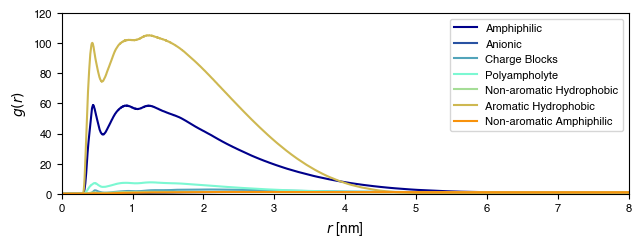

In [31]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((16*cm), (6*cm)), constrained_layout=True)
martini_peptides = ['amphiphilic', 'anionic', 'charge_blocks', 
                    'polyampholyte', 'non_aromatic_hydrophobic', 'aromatic_hydrophobic', 
                    'non_aromatic_amphiphilic']

def load_rdf(path, color_pick):
    temp = np.arange(10)
    pairs = np.array(list(combinations(temp, 2)))
    counter = 0
    for pair in pairs:
        dist, rdf = np.genfromtxt((path + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                                  usecols=(0, 1), skip_header=25, unpack=True)
        if counter == 0:
            rdf_ave = rdf
        else:
            rdf_ave += rdf
        counter += 1
    rdf_ave = rdf_ave/counter
    ax.plot(dist, rdf_ave, color=color_list[color_pick])

counter = 0
for peptide in martini_peptides:
    load_rdf((work_dir + '150mM_' + peptide + '/rdfs/'), counter)
    counter += 16
    
ax.set_ylim(0, 120)
ax.set_xlim(0, 8)
ax.set_ylabel('$g(r)$', fontsize=font_label)
ax.set_xlabel('$r$ [nm]', fontsize=font_label)
ax.tick_params(labelsize=font)
ax.legend(['Amphiphilic', 'Anionic', 'Charge Blocks', 
           'Polyampholyte', 'Non-aromatic Hydrophobic', 'Aromatic Hydrophobic', 
           'Non-aromatic Amphiphilic'], fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/MARTINI_model_pep.pdf', dpi=1000)